<a href="https://colab.research.google.com/github/dylankirby1130/microprocessorlab/blob/master/mnist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Loading Datasets and Importing Libraries

In [2]:
# Importing Tensorflow and the required visualization libraries
import tensorflow as tf
tf.config.run_functions_eagerly(True)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

#Loading the Dataset
train = pd.read_csv('/content/drive/MyDrive/HW4/train.csv')
test = pd.read_csv('/content/drive/MyDrive/HW4/test.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Seperating the independent feature as y
y = train['label']
train = train.drop('label', axis =1)

# Visualizing Data

<Axes: ylabel='count'>

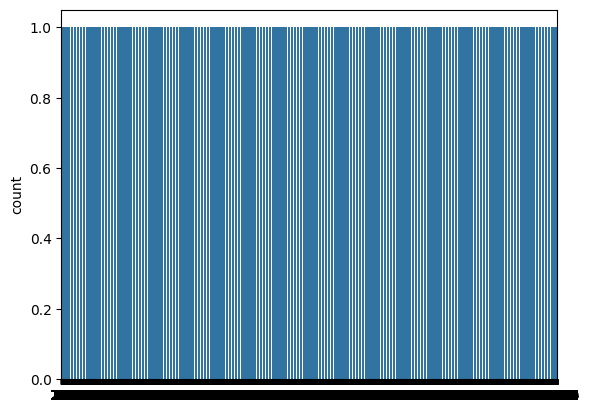

In [4]:
#Visualizing the Distribution of digits in labels
sns.countplot(y)

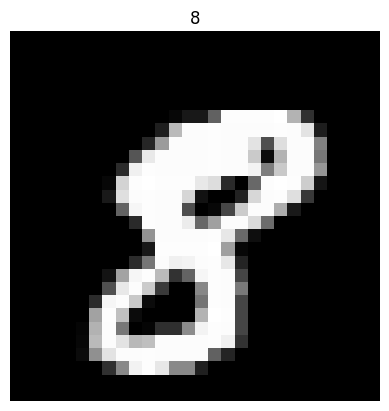

In [5]:
#Visualing an example
img = train.iloc[10].to_numpy()
img = img.reshape((28,28))
plt.imshow(img,cmap='gray')
plt.title(y.iloc[10])
plt.axis("off")
plt.show()

# Preprocessing Data

In [6]:
#Preprocessing the Data
train=train/225.0
test = test/225.0
train = np.array(train)
test= np.array(test)
train = train.reshape(train.shape[0], 28, 28,1)
test = test.reshape(test.shape[0], 28, 28,1)

#Splitting the data into training and validation
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(train, y, test_size=0.2)

#Converting the train and validation labels to one-hot encodings
Y_train = tf.keras.utils.to_categorical(Y_train, num_classes=10)
Y_val = tf.keras.utils.to_categorical(Y_val, num_classes=10)

# Building, Compiling and Training model

In [66]:
tf.keras.backend.clear_session()

In [67]:
#Preparing a CNN model architecture
# Part (e) model: original architecture
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (5,5), activation='relu', kernel_initializer='he_uniform', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(64, (5,5), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


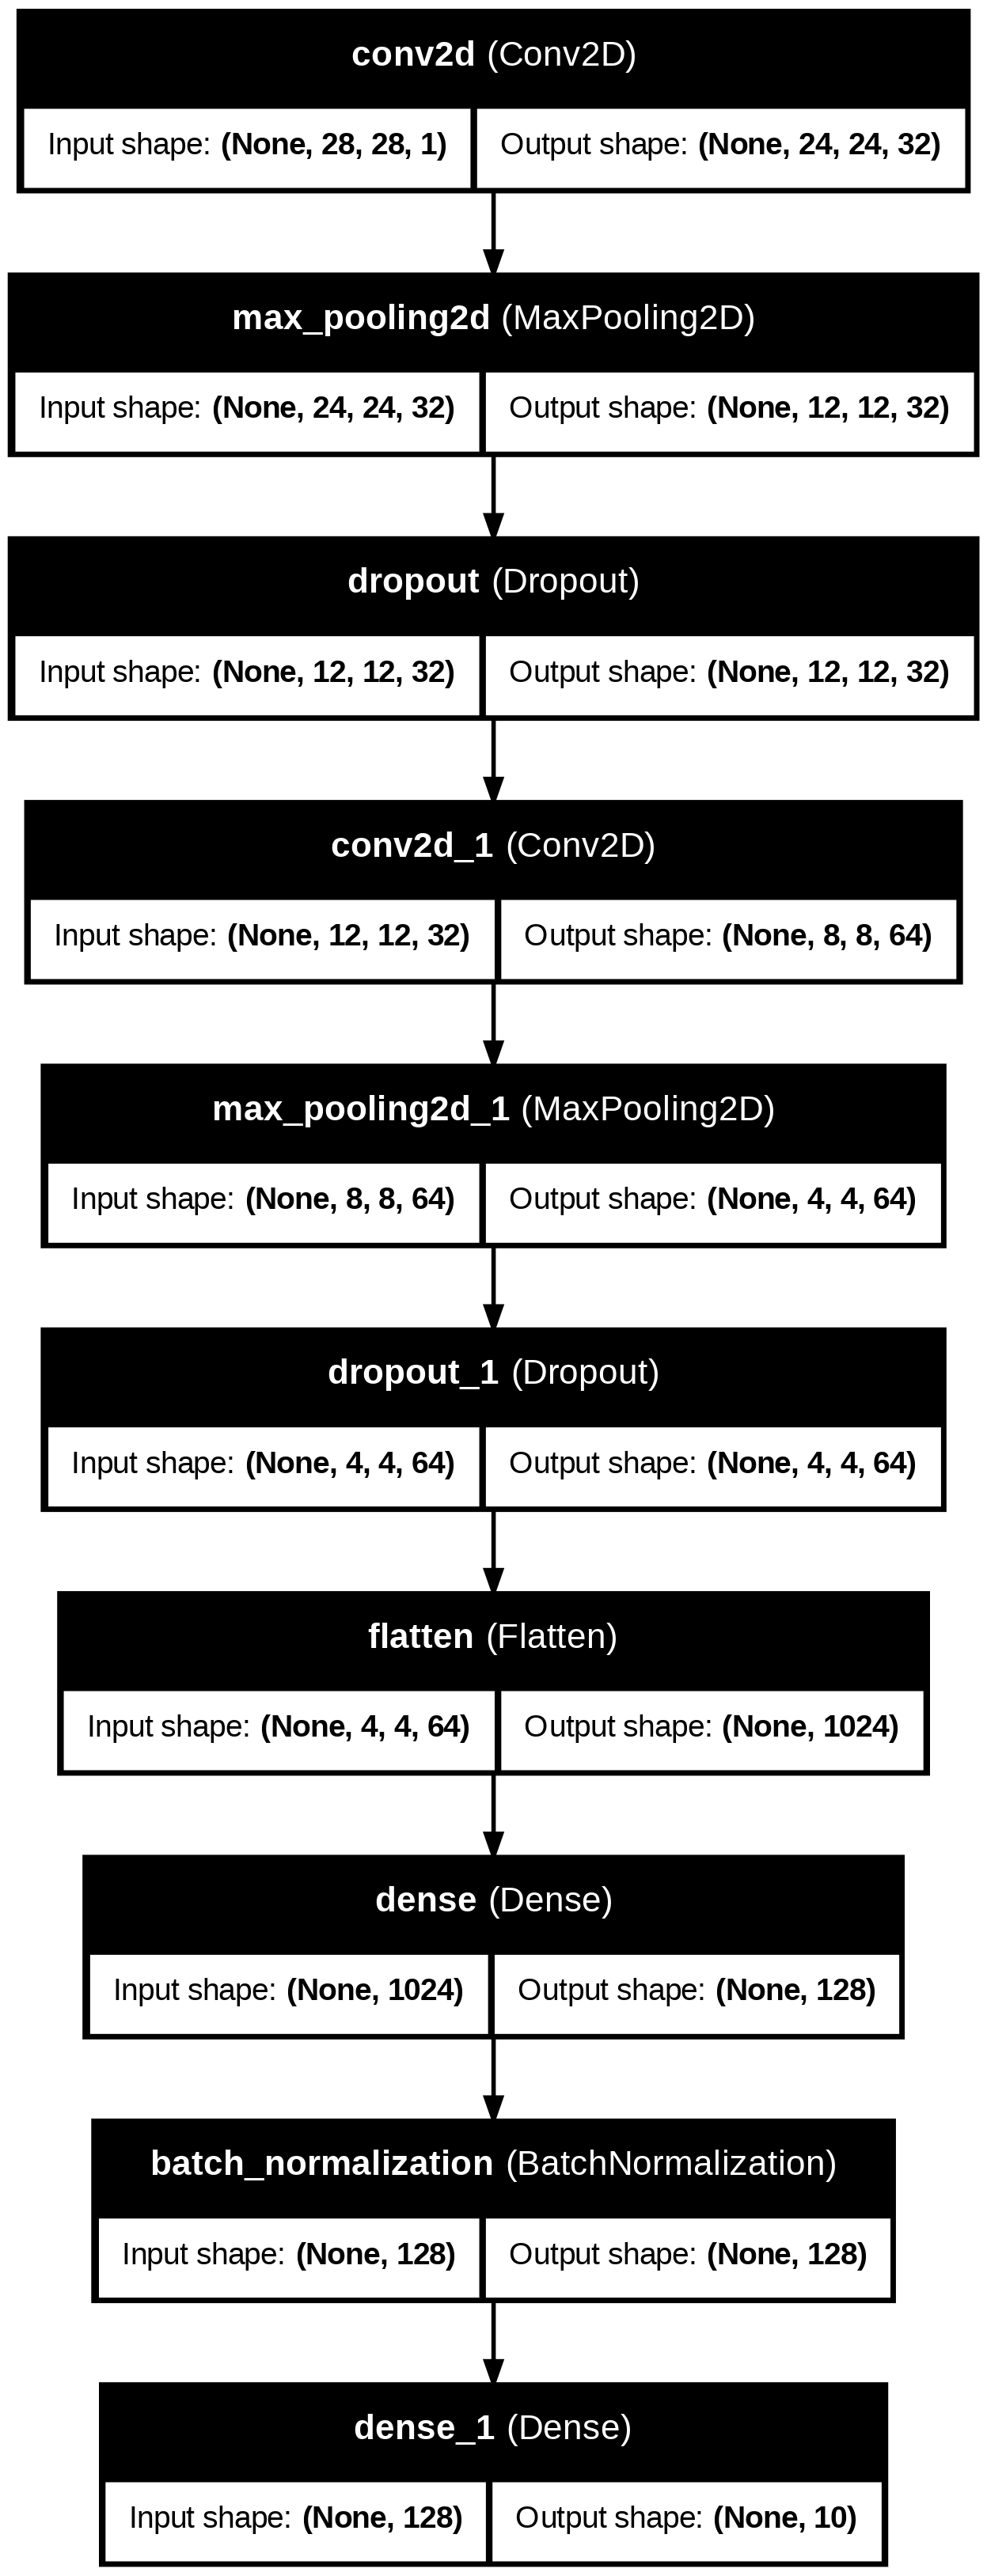

In [68]:
# Getting the model framework/summary
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)
display(Image(filename='model.png'))

In [69]:
#Compiling the model
model.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.2, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

In [70]:
#Data augmentation to prevent overfitting
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rotation_range=30,
        zoom_range = 0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,)

In [71]:
#Training the model
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 168ms/step - accuracy: 0.9308 - loss: 0.2194 - val_accuracy: 0.9789 - val_loss: 0.0669
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 167ms/step - accuracy: 0.9755 - loss: 0.0793 - val_accuracy: 0.9849 - val_loss: 0.0522
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 142s 168ms/step - accuracy: 0.9809 - loss: 0.0627 - val_accuracy: 0.9829 - val_loss: 0.0577
Epoch 4/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 88s 167ms/step - accuracy: 0.9833 - loss: 0.0523 - val_accuracy: 0.9885 - val_loss: 0.0376
Epoch 5/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 87s 165ms/step - accuracy: 0.9849 - loss: 0.0476 - val_accuracy: 0.9904 - val_loss: 0.0300
Epoch 6/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 90s 172ms/step - accuracy: 0.9877 - loss: 0.0400 - val_accuracy: 0.9880 - val_loss: 0.0409
Epoch 7/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 86s 165ms/step - accuracy: 0.9885 - loss: 0.0377 - val_accuracy: 0.9877 - val_loss: 0.0461
Epoch 8/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 143s 167ms/step - accuracy: 0.9889 - loss:

# Evaluating Results

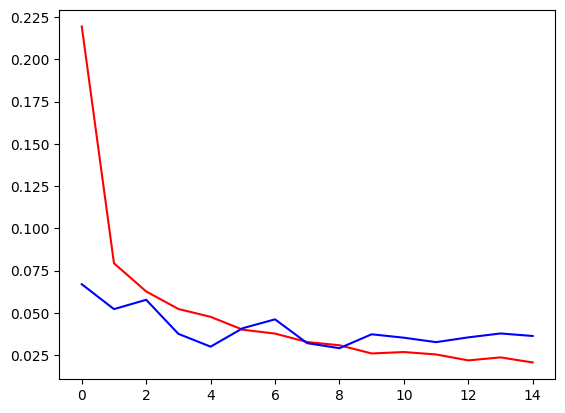

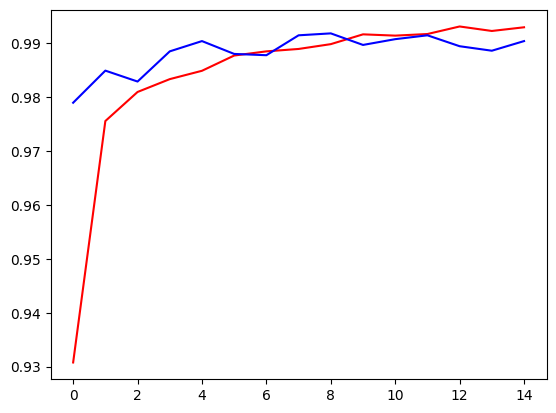

In [72]:
#Comparing losses and accuraries
plt.plot(history.history['loss'], color='r')
plt.plot(history.history['val_loss'], color='b')
plt.show()
plt.plot(history.history['accuracy'], color='r')
plt.plot(history.history['val_accuracy'], color='b')
plt.show()

In [73]:
#Plotting Confusion Matrix
y_pred1 = model.predict(X_val)
y_pred1 = np.argmax(y_pred1, axis=1)
y_true = np.argmax(Y_val, axis=1)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred1)
print(cm)

263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
[[833   0   1   0   0   1   4   4   1   1]
 [  0 924   1   0   4   0   0   3   0   0]
 [  0   0 864   0   1   0   1   3   0   0]
 [  0   0   1 865   0   4   0   1   2   1]
 [  1   0   1   0 786   0   1   0   0   5]
 [  0   0   0   0   0 730   4   0   0   0]
 [  0   0   0   0   1   1 816   0   1   0]
 [  0   2   3   0   0   0   0 898   0   0]
 [  0   1   3   0   2   2   0   1 755   3]
 [  0   0   0   0   8   0   1   5   1 848]]


# Saving the Predictions

In [74]:
#Predicting and Saving it as a CSV file
y_pred = model.predict(test)
y_pred = np.argmax(y_pred, axis=1)
y_pred = pd.Series(y_pred, name='Label')
sub = pd.concat([pd.Series(range(1, 28001), name="ImageId"), y_pred], axis=1)
sub.to_csv('/content/drive/MyDrive/HW4/RESULTS.csv', index=False)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


875/875 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step


# ============================================================
# UNCOMMENT / CHANGE FOR EACH PART
# ============================================================

# experiment_name = "baseline"
# experiment_name = "part_a_64_128"
# experiment_name = "part_b_3conv_32_64_32"
# experiment_name = "part_c_no_dropout"
# experiment_name = "part_d_lr_0_2"
# experiment_name = "part_e_no_augmentation"

875/875 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step


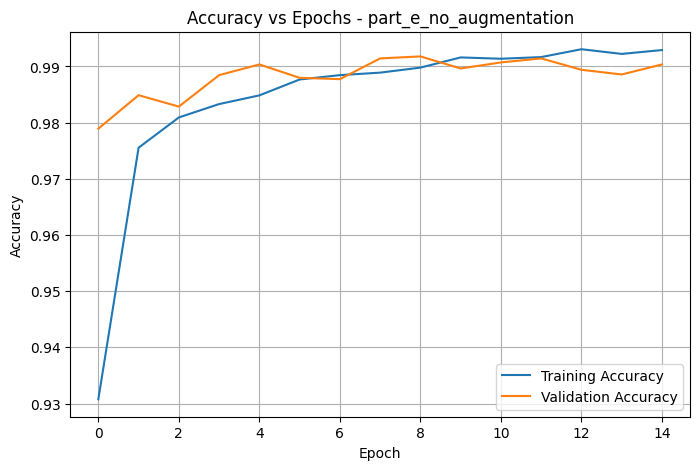

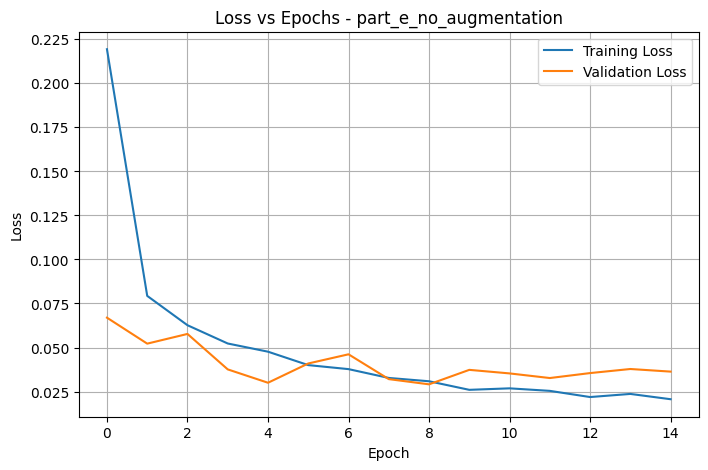

263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step


<Figure size 800x800 with 0 Axes>

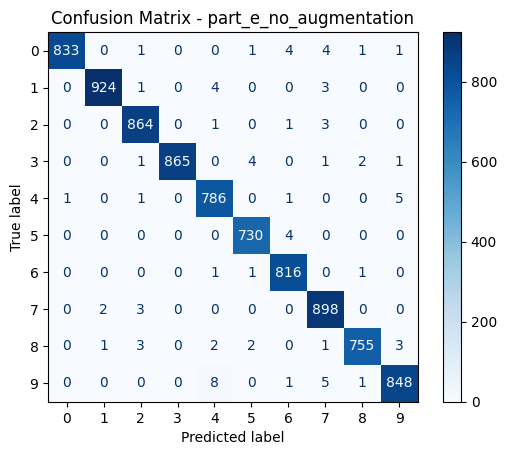

Experiment saved: part_e_no_augmentation
Files created:
/content/drive/MyDrive/HW4/RESULTS_part_e_no_augmentation.csv
/content/drive/MyDrive/HW4/accuracy_plot_part_e_no_augmentation.png
/content/drive/MyDrive/HW4/loss_plot_part_e_no_augmentation.png
/content/drive/MyDrive/HW4/confusion_matrix_part_e_no_augmentation.png
/content/drive/MyDrive/HW4/confusion_matrix_part_e_no_augmentation.csv
/content/drive/MyDrive/HW4/metrics_part_e_no_augmentation.txt
/content/drive/MyDrive/HW4/metrics_part_e_no_augmentation.json
/content/drive/MyDrive/HW4/experiment_summary.csv
Final Training Accuracy   : 0.992917
Final Validation Accuracy : 0.990357
Final Training Loss       : 0.020631
Final Validation Loss     : 0.036311
Kaggle Accuracy           : enter manually after submission


In [75]:
## ============================================================
# FINAL RESULTS / EXPORT CELL
# Change experiment_name each time you run a new homework part
# Then run this cell after training is complete
# ============================================================

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SET THIS FOR THE CURRENT RUN
# ------------------------------------------------------------
#experiment_name = "baseline"
# examples:
#experiment_name = "part_a_64_128"
#experiment_name = "part_b_3conv_32_64_32"
#experiment_name = "part_c_no_dropout"
#experiment_name = "part_d_lr_0_2"
experiment_name = "part_e_no_augmentation"

save_dir = "/content/drive/MyDrive/HW4"
os.makedirs(save_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. SAVE PREDICTIONS CSV FOR KAGGLE
# ------------------------------------------------------------
y_pred_test = model.predict(test)
y_pred_test = np.argmax(y_pred_test, axis=1)

submission = pd.concat(
    [
        pd.Series(range(1, len(y_pred_test) + 1), name="ImageId"),
        pd.Series(y_pred_test, name="Label")
    ],
    axis=1
)

csv_path = os.path.join(save_dir, f"RESULTS_{experiment_name}.csv")
submission.to_csv(csv_path, index=False)

# ------------------------------------------------------------
# 2. EXTRACT FINAL TRAIN / VALIDATION METRICS
# ------------------------------------------------------------
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

epochs_ran = len(history.history["accuracy"])

# ------------------------------------------------------------
# 3. SAVE ACCURACY PLOT
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Accuracy vs Epochs - {experiment_name}")
plt.legend()
plt.grid(True)
acc_plot_path = os.path.join(save_dir, f"accuracy_plot_{experiment_name}.png")
plt.savefig(acc_plot_path, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4. SAVE LOSS PLOT
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss vs Epochs - {experiment_name}")
plt.legend()
plt.grid(True)
loss_plot_path = os.path.join(save_dir, f"loss_plot_{experiment_name}.png")
plt.savefig(loss_plot_path, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5. SAVE CONFUSION MATRIX ON VALIDATION SET
# ------------------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_val_pred = model.predict(X_val)
y_val_pred = np.argmax(y_val_pred, axis=1)
y_val_true = np.argmax(Y_val, axis=1)   # assumes one-hot labels

cm = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {experiment_name}")
cm_plot_path = os.path.join(save_dir, f"confusion_matrix_{experiment_name}.png")
plt.savefig(cm_plot_path, bbox_inches="tight")
plt.show()

# also save raw confusion matrix as csv
cm_df = pd.DataFrame(cm)
cm_csv_path = os.path.join(save_dir, f"confusion_matrix_{experiment_name}.csv")
cm_df.to_csv(cm_csv_path, index=False)

# ------------------------------------------------------------
# 6. SAVE METRICS TXT FILE
# ------------------------------------------------------------
metrics_txt_path = os.path.join(save_dir, f"metrics_{experiment_name}.txt")
with open(metrics_txt_path, "w") as f:
    f.write(f"Experiment: {experiment_name}\n")
    f.write(f"Epochs: {epochs_ran}\n")
    f.write(f"Final Training Accuracy: {final_train_acc:.6f}\n")
    f.write(f"Final Validation Accuracy: {final_val_acc:.6f}\n")
    f.write(f"Final Training Loss: {final_train_loss:.6f}\n")
    f.write(f"Final Validation Loss: {final_val_loss:.6f}\n")
    f.write("\n")
    f.write("Kaggle Accuracy: ENTER MANUALLY AFTER SUBMISSION\n")

# ------------------------------------------------------------
# 7. SAVE METRICS JSON FILE
# ------------------------------------------------------------
metrics_dict = {
    "experiment": experiment_name,
    "epochs": epochs_ran,
    "final_train_accuracy": float(final_train_acc),
    "final_val_accuracy": float(final_val_acc),
    "final_train_loss": float(final_train_loss),
    "final_val_loss": float(final_val_loss),
    "kaggle_accuracy": None
}

metrics_json_path = os.path.join(save_dir, f"metrics_{experiment_name}.json")
with open(metrics_json_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

# ------------------------------------------------------------
# 8. APPEND TO SUMMARY CSV
# ------------------------------------------------------------
summary_path = os.path.join(save_dir, "experiment_summary.csv")

new_row = pd.DataFrame([{
    "Experiment": experiment_name,
    "Final_Train_Accuracy": final_train_acc,
    "Final_Validation_Accuracy": final_val_acc,
    "Final_Train_Loss": final_train_loss,
    "Final_Validation_Loss": final_val_loss,
    "Kaggle_Accuracy": ""
}])

if os.path.exists(summary_path):
    summary_df = pd.read_csv(summary_path)
    summary_df = pd.concat([summary_df, new_row], ignore_index=True)
else:
    summary_df = new_row

summary_df.to_csv(summary_path, index=False)

# ------------------------------------------------------------
# 9. PRINT SUMMARY
# ------------------------------------------------------------
print("============================================================")
print(f"Experiment saved: {experiment_name}")
print("Files created:")
print(csv_path)
print(acc_plot_path)
print(loss_plot_path)
print(cm_plot_path)
print(cm_csv_path)
print(metrics_txt_path)
print(metrics_json_path)
print(summary_path)
print("============================================================")
print(f"Final Training Accuracy   : {final_train_acc:.6f}")
print(f"Final Validation Accuracy : {final_val_acc:.6f}")
print(f"Final Training Loss       : {final_train_loss:.6f}")
print(f"Final Validation Loss     : {final_val_loss:.6f}")
print("Kaggle Accuracy           : enter manually after submission")
print("============================================================")